# 🤖 Project Overview: Regression Model Selection and Hyperparameter Tuning

This exercise serves as a practical introduction to **Regression Problems** in Machine Learning, focusing on the standard workflow: **Data Splitting**, **Model Selection**, **Training**, **Evaluation**, and **Hyperparameter Tuning** using the popular `scikit-learn` (sklearn) library.

---

## 📉 Core Machine Learning Workflow

The initial tasks demonstrate how different data subsets and model choices lead to varying performance and predictive errors.

| Task | ML/Data Science Principle | Concept Demonstrated |
| :--- | :--- | :--- |
| **Ex. 1.1** | **Data Splitting & Linear Modeling** | **Underfitting (High Bias):** Fitting a simple **Linear Regression** model to a complex data segment ($x < 10$). The low MSE might be misleading when the model is forced to extrapolate to the rest of the dataset ($x > 10$). |
| **Ex. 1.2** | **Model Selection & Extrapolation** | **Model Comparison:** Fitting both **Linear Regression** (simple/low variance) and **RandomForest Regressor** (complex/high variance) to the second segment. Predicting the missing segment ($x < 10$) highlights how the model choice impacts **generalization** and **extrapolation**. |
| **Ex. 1.3** | **Ensemble Modeling (Custom)** | **Model Integration:** Creating a simple **Composite Model** "by hand" by combining predictions from the two segmented models. This illustrates a basic form of **Ensemble Learning** where different experts (models) cover different parts of the feature space. |
| **Ex. 1.4** | **Overfitting/Underfitting Assessment** | **Performance Analysis:** Training the complex **RandomForest Regressor** on the *entire* dataset. Comparing this MSE to the previous segmented MSEs reveals if the combined model in Ex. 1.3 effectively managed the complexity better than a single model trained on the entire, varied dataset. This is where **overfitting** or **underfitting** would be formally assessed. |

---

## 🛠️ Hyperparameter Tuning and Optimization

This task dives into the core practice of **Hyperparameter Tuning**—optimizing model performance by adjusting settings external to the training process.

| Task | ML/Data Science Principle | Concept Demonstrated |
| :--- | :--- | :--- |
| **Ex. 1.5** | **Hyperparameter Tuning (n_estimators)** | **Bias-Variance Trade-off:** Systematically varying the `n_estimators` hyperparameter of the **RandomForest Regressor** (the number of decision trees). |
| **Ex. 1.5** | **Evaluation Curve Analysis** | **Plotting MSE vs. n\_estimators** shows that as the number of estimators increases, the model's performance (MSE) typically improves and then plateaus. This helps identify the **optimal hyperparameter value** where performance gain no longer justifies the added computational cost. |

---

## 🔑 Critical Data Science Principles

* **Normalization:** The hint emphasizes the need to **normalize the data** before training, which is a standard **data preprocessing** step, especially critical for distance-based or gradient-descent-based models (though less so for Random Forests, it's a best practice).
* **Performance Metric:** **Mean Squared Error (MSE)** is consistently used as the evaluation metric, quantifying the average squared difference between the predicted and actual values.
* **Generalization vs. Extrapolation:** The exercise highlights that a model performing well on its training data segment may fail when asked to **extrapolate** (predict outside its trained range, e.g., Ex 1.1 predictions on $x \in [10, 30]$).

<class 'numpy.ndarray'>
1
(33,)
mean squared error(train)= 1.1413428077232624
mean squared error(test)= 441.241739051044


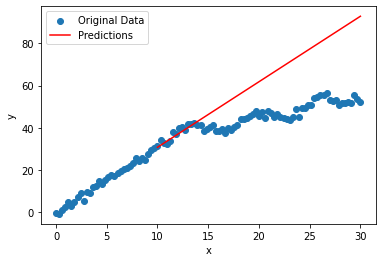

In [14]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# data loading:
data=np.loadtxt("HW02_data.csv",delimiter=",",skiprows=1)
x=data[:,0]
y=data[:,1]
mask=x<10
data1_x = x[mask]
data1_y = y[mask]
data2_x = x[~mask]
data2_y = y[~mask]


print(type(data1_y))
print(data1_y.ndim)
print(data1_y.shape)


model= LinearRegression()
model.fit(data1_x.reshape(-1,1),data1_y)


y_pred=model.predict(data1_x.reshape(-1,1))
mse=mean_squared_error(data1_y,y_pred)
print("mean squared error(train)=",mse)

y_pred2=model.predict(data2_x.reshape(-1,1))
mse2=mean_squared_error(data2_y,y_pred2)
print("mean squared error(test)=",mse2)

x_new=np.arange(10,31)
y_pred_new=model.predict(x_new.reshape(-1,1))



plt.scatter(x, y, label="Original Data")
plt.plot(x_new, y_pred_new, color="red", label="Predictions")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()



The model has been trained on data that appears to follow well enough a linear model that is  is too simple for the rest of the data and doesn't fit properly. In this case, it seems to be underfitting rather than overfitting.

Linear Regression MSE:(train) 5.763037820436946
Linear Regression MSE:(test) 260.6409963357523
Random Forest Regressor MSE:(train) 0.3170634402442137
Random Forest Regressor MSE:(test) 388.78348799754434


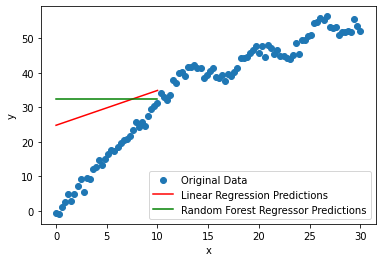

In [9]:
# Linear Regression
model_lr = LinearRegression()
model_lr.fit(data2_x.reshape(-1, 1), data2_y)

# Random Forest
model_rf = RandomForestRegressor()
model_rf.fit(data2_x.reshape(-1, 1), data2_y)

y_pred_lr1 = model_lr.predict(data2_x.reshape(-1, 1))
mse_lr1 = mean_squared_error(data2_y, y_pred_lr1)
print("Linear Regression MSE:(train)", mse_lr1)

y_pred_lr2 = model_lr.predict(data1_x.reshape(-1, 1))
mse_lr2 = mean_squared_error(data1_y, y_pred_lr2)
print("Linear Regression MSE:(test)", mse_lr2)

y_pred_rf3 = model_rf.predict(data2_x.reshape(-1, 1))
mse_rf1 = mean_squared_error(data2_y, y_pred_rf3)
print("Random Forest Regressor MSE:(train)", mse_rf1)

y_pred_rf4 = model_rf.predict(data1_x.reshape(-1, 1))
mse_rf2 = mean_squared_error(data1_y, y_pred_rf4)
print("Random Forest Regressor MSE:(test)", mse_rf2)


x_new = np.linspace(0, 10,100)
y_pred_lr_new = model_lr.predict(x_new.reshape(-1, 1))
y_pred_rf_new = model_rf.predict(x_new.reshape(-1, 1))

plt.scatter(x, y, label="Original Data")
plt.plot(x_new, y_pred_lr_new, color="red", label="Linear Regression Predictions")
plt.plot(x_new, y_pred_rf_new, color="green", label="Random Forest Regressor Predictions")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()




We observe that while the random forest model seems to fit the training data better as we can see from the lower MSE(train) , it generalizes worse to the test data than the linear model as we can see from the higher MSE(test). This is a case of overfitting for the random forest model, however this term maybe does not make much sense here since the model has been trained on part of the data that is not representative of the whole dataset (this could be said about the previous case as well).

Combined MSE: 0.5890756315122998


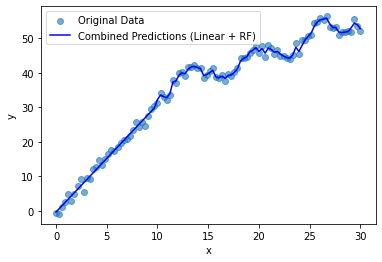

In [17]:
x_combined = np.concatenate((data1_x, data2_x))
y_pred_combined = np.concatenate((model.predict(data1_x.reshape(-1, 1)), model_rf.predict(data2_x.reshape(-1, 1))))
mse_combined = mean_squared_error(y, y_pred_combined)
print("Combined MSE:", mse_combined)

# combined predictions along with the whole dataset
plt.scatter(x, y, label="Original Data", alpha=0.6)
plt.plot(x_combined, y_pred_combined, color="blue", label="Combined Predictions (Linear + RF)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

Random Forest Regressor MSE: 128.51098354415325


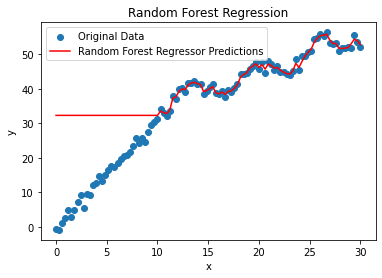

In [21]:
# Random Forest
model_rf5 = RandomForestRegressor()
model_rf5.fit(data[:,0].reshape(-1, 1),data[:,1])


y_pred_rf5 = model_rf.predict(data[:,0].reshape(-1, 1))
mse_rf5 = mean_squared_error(data[:,1], y_pred_rf5)
print("Random Forest Regressor MSE:", mse_rf5)


plt.scatter(data[:, 0], data[:, 1], label="Original Data")
plt.plot(data[:, 0], y_pred_rf5, color="red", label="Random Forest Regressor Predictions")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Random Forest Regression")
plt.legend()
plt.show()


In this case random forest regressor fits properly the x>10 data but doesnt on the x<10 data. This shows us that the model performs much better on complex than linear data .The models inability to fit the first data results in a high mse and overfitting.

Random Forest Regressor MSE: 2.8525083839074576
Random Forest Regressor MSE: 2.667636953725107
Random Forest Regressor MSE: 2.9670572111525972
Random Forest Regressor MSE: 2.571565027818246
Random Forest Regressor MSE: 2.534442200101151
Random Forest Regressor MSE: 2.2011621251917965
Random Forest Regressor MSE: 2.2931113813011637
Random Forest Regressor MSE: 2.408230380207626
Random Forest Regressor MSE: 2.125294791702641
Random Forest Regressor MSE: 2.2638455918357154
Random Forest Regressor MSE: 2.204414007791932
Random Forest Regressor MSE: 2.1478653326368278
Random Forest Regressor MSE: 2.154629794254515
Random Forest Regressor MSE: 2.3753707697293587
Random Forest Regressor MSE: 2.1273307547063376
Random Forest Regressor MSE: 2.390595358565798
Random Forest Regressor MSE: 2.267999236475837
Random Forest Regressor MSE: 2.07378638246299
Random Forest Regressor MSE: 2.376340428996344
Random Forest Regressor MSE: 2.5151478837334085
Random Forest Regressor MSE: 2.204500775398544
Rando

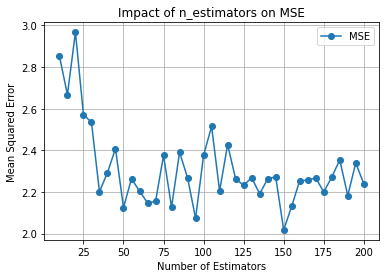

In [19]:
from sklearn.model_selection import train_test_split

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(data[:, 0].reshape(-1, 1), data[:, 1], test_size=0.2, random_state=np.random.seed(42))

n_estimators = np.arange(10, 201, 5)

mse_array = []
for n in n_estimators:
    model_rf3 = RandomForestRegressor(n_estimators=n)
    model_rf3.fit(X_train, y_train)
    y_pred_rf3 = model_rf3.predict(X_val)
    mse_rf3 = mean_squared_error(y_val, y_pred_rf3)
    print("Random Forest Regressor MSE:", mse_rf3)
    mse_array.append(mse_rf3)
    
min_mse_index = np.argmin(mse_array)
min_mse = mse_array[min_mse_index]
print("Minimum MSE:", min_mse)
print("Optimal n_estimators:", n_estimators[min_mse_index])


    
# MSE as a function of n_estimators
plt.plot(n_estimators, mse_array, marker='o', label='MSE')
plt.xlabel("Number of Estimators")
plt.ylabel("Mean Squared Error")
plt.title("Impact of n_estimators on MSE")
plt.grid(True)
plt.legend()
plt.show()


The optimal number of estimators is 150 as it gives the lowest MSE. We can see that a very small number of estimators results in a higher MSE but after around 30 estimators the MSE stabilizes and doesn't change that much. Comparing it to the previous random forest regressor model we can see that it is much lower. However this comparison is not fair since the MSE here is calculated only on the test data and not on the whole dataset.Of course in general the more points you have the higher your MSE will be. However the combined model still has a lower MSE(even despite the fact that it was calculated on the whole dataset).